# Model Evalutions and Visualization

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from adan_pytorch import Adan

# saved onto .py files after prev notebook runs for reusability
from include.model.vimo_type2 import ViMoFrameWorkv1, ViMoFrameWorkv2 
from include.dataset import ViMoDataset
from include.loss_utils import get_joint_positions, compact_optim_str
from include.ddpm_utils import make_beta_schedule, forward_diffusion_sample, reverse_denoising_sample

# Lambda values for legend (based on prev configuration while training model)
lambda_values = "(λ_joints=1, λ_vel=1, λ_foot=1) - reconfigured"
OUT_DIR = Path.cwd() / "outputs"

# simulation id (important, refer Training notebook)
model_version = 1
run_id = f"_v{model_version}_warm50" 
# config others accordingly
motion_dim 		= 151
pose_dim 		= 17*3
diffsteps 		= 1000
embed_dim 		= 128
n_heads 		= 4   
m_nlayers 		= 3   
p_nlayers 		= 2   
cond_drop 		= 0.25

# update vimo model and optim params here (refer framework)
if model_version == 1:
	model = ViMoFrameWorkv1(motion_dim=motion_dim, pose_dim=pose_dim, max_T=diffsteps, embed_dim=embed_dim,
                    		n_heads=n_heads, m_nlayers=m_nlayers, p_nlayers=p_nlayers, cond_drop=cond_drop)
elif model_version == 2:
	model = ViMoFrameWorkv2(motion_dim=motion_dim, pose_dim=pose_dim, max_T=diffsteps, embed_dim=embed_dim,
                    		n_heads=n_heads, m_nlayers=m_nlayers, p_nlayers=p_nlayers, cond_drop=cond_drop)
optimizer = Adan(model.parameters(), weight_decay=0.02)

In [48]:
RUN_DIR = MODEL_DIR = OUT_DIR / f"{model.compact_name}_{compact_optim_str(optimizer)}/run{run_id}"
MODEL_DIR = RUN_DIR / "models"
PLOT_DIR = RUN_DIR / "plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# need model to get its corresponding model name along with its corresponding prefix
loss_csv_file = MODEL_DIR / "Loss.csv"
df = pd.read_csv(loss_csv_file)  # Read the CSV file

# Display the first few rows to understand the structure
print("Original Data Shape:", df.shape)

# Display column names
print("\nColumns:")
print(df.columns.tolist())

Original Data Shape: (10250, 12)

Columns:
['epoch', 'step', 'L_total', 'L_simple', 'L_joints', 'L_vel', 'L_foot', 'VL_total', 'VL_simple', 'VL_joints', 'VL_vel', 'VL_foot']


In [49]:
# Create a copy for manipulation
df_clean = df.copy()

# Get all column names with VL_ prefix
vl_columns = [col for col in df_clean.columns if col.startswith('VL_')]
l_columns = [col for col in df_clean.columns if col.startswith('L_')]

print(f"Training loss columns: {l_columns}")
print(f"Validation loss columns: {vl_columns}")

# Convert validation columns to numeric, replacing non-numeric with NaN
for col in vl_columns:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Display info about missing values
print("\nMissing values in validation columns:")
for col in vl_columns:
    missing = df_clean[col].isna().sum()
    print(f"{col}: {missing} ({missing/len(df_clean)*100:.2f}%)")

# update 'total' loss value with std lambda values (all being 1)
df_clean['L_total'] = df_clean[['L_simple', 'L_joints', 'L_vel', 'L_foot']].sum(axis=1)
df_clean['VL_total'] = df_clean[['VL_simple', 'VL_joints', 'VL_vel', 'VL_foot']].sum(axis=1)

print("\nFirst few rows:")
print(df_clean.head())

Training loss columns: ['L_total', 'L_simple', 'L_joints', 'L_vel', 'L_foot']
Validation loss columns: ['VL_total', 'VL_simple', 'VL_joints', 'VL_vel', 'VL_foot']

Missing values in validation columns:
VL_total: 8200 (80.00%)
VL_simple: 8200 (80.00%)
VL_joints: 8200 (80.00%)
VL_vel: 8200 (80.00%)
VL_foot: 8200 (80.00%)

First few rows:
   epoch  step   L_total  L_simple  L_joints     L_vel    L_foot  VL_total  \
0      1   128  4.328678  0.734991  2.493643  0.195644  0.904400  0.000000   
1      1   256  4.164435  0.732875  2.398361  0.180748  0.852451  0.000000   
2      1   384  3.567135  0.658454  2.322885  0.179707  0.406088  0.000000   
3      1   512  3.173960  0.585171  2.190725  0.152808  0.245256  0.000000   
4      1   640  2.836880  0.519098  2.020001  0.126063  0.171718  2.636147   

   VL_simple  VL_joints    VL_vel   VL_foot  
0        NaN        NaN       NaN       NaN  
1        NaN        NaN       NaN       NaN  
2        NaN        NaN       NaN       NaN  
3        

## Losses Plot:

In [50]:
# Define loss components and color swatchs for plots
loss_components = ['simple', 'joints', 'vel', 'foot', 'temporal', 'diversity']
colors = ['#11DDFF', '#660B66', '#247ED7', '#AA1B67']
colors_val = ['#937CB5', '#37B1A3', '#B8A471', '#BB7070', '#47AADB', '#D990EC'] # lighter
colors_train = ['#0A212A', '#093B2E', '#513711', '#31150F', '#002999', '#7C0E56'] # darker

### Losses vs epoch.step

In [51]:
# Create epoch.step column if not exists
if 'epoch.step' not in df_clean.columns:
    # Assuming you have 'epoch' and 'step' columns
    df_clean['epoch.step'] = df_clean['epoch'].astype(str) + '.' + df_clean['step'].astype(str)
    # Convert to numeric for plotting
    df_clean['epoch_step_numeric'] = df_clean['epoch']-1 + df_clean['step'] / (df_clean['step'].max())

#### Total Loss vs epoch.step

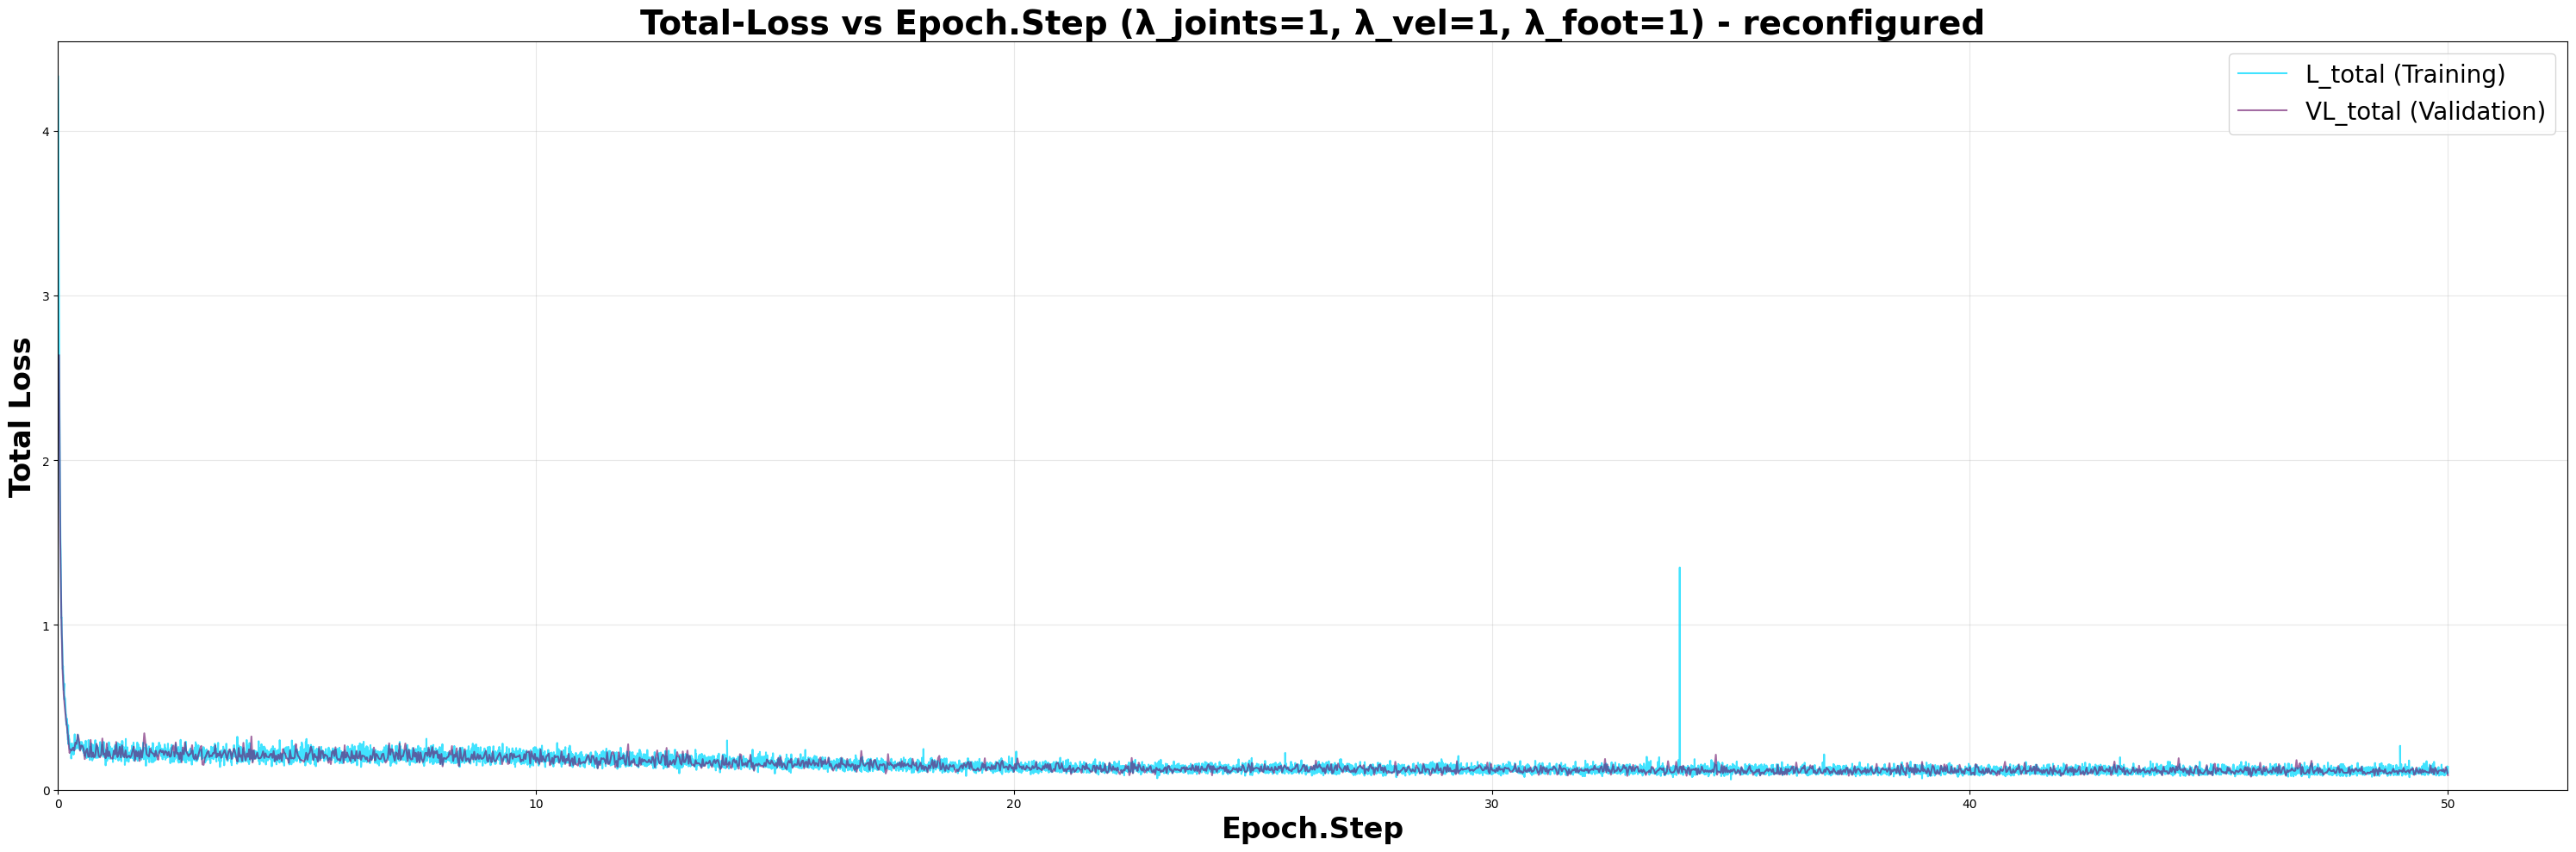

In [52]:
# Plot L_total and VL_total vs epoch.step
plt.figure(figsize=(30, 10))

# Plot training loss
plt.plot(df_clean['epoch_step_numeric'], df_clean['L_total'], 
         label=f'L_total (Training)', color=colors[0], linewidth=1.5, alpha=0.8)

# Plot validation loss (drop NaN values for plotting)
valid_mask = ~(df_clean[['VL_simple', 'VL_joints', 'VL_vel', 'VL_foot']].isna().any(axis=1) | (df_clean['VL_total'] == 0))
plt.plot(df_clean.loc[valid_mask, 'epoch_step_numeric'], df_clean.loc[valid_mask, 'VL_total'], 
         label=f'VL_total (Validation)', color=colors[1], linewidth=1.5, alpha=0.6)

plt.xlabel('Epoch.Step', fontsize=24, fontweight='bold')
plt.ylabel('Total Loss', fontsize=24, fontweight='bold')
plt.title(f'Total-Loss vs Epoch.Step {lambda_values}', fontsize=28, fontweight='bold')
plt.legend(fontsize=20)
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig(PLOT_DIR/("#1 "+plt.gca().get_title()+'.png'))
plt.show()

In [53]:
# Plot L_std and VL_std vs epoch.step
plt.figure(figsize=(30, 10))

# Plot training std
plt.plot(df_clean['epoch_step_numeric'], df_clean['L_gt_std'], 
         label=f'L_gt_std (Training - Ground Truth)', color=colors[2], linewidth=1.25, linestyle='--', alpha=0.5)

plt.plot(df_clean['epoch_step_numeric'], df_clean['L_pred_std'], 
         label=f'L_pred_std (Training - Prediction)', color=colors[0], linewidth=1.5, alpha=0.6)

# Plot validation std (drop NaN values for plotting)
valid_mask = ~(df_clean[['VL_simple', 'VL_joints', 'VL_vel', 'VL_foot']].isna().any(axis=1) | (df_clean['VL_total'] == 0))

plt.plot(df_clean.loc[valid_mask, 'epoch_step_numeric'], df_clean.loc[valid_mask, 'VL_gt_std'], 
         label=f'VL_gt_std (Validation - Ground Truth)', color=colors[3], linewidth=1.25, linestyle='--', alpha=0.4)

plt.plot(df_clean.loc[valid_mask, 'epoch_step_numeric'], df_clean.loc[valid_mask, 'VL_pred_std'], 
         label=f'VL_pred_std (Validation - Prediction)', color=colors[1], linewidth=1.5, alpha=0.5)

plt.xlabel('Epoch.Step', fontsize=24, fontweight='bold')
plt.ylabel('Standard Deviation Across Frames', fontsize=24, fontweight='bold')
plt.title(f'Standard Deviation vs Epoch.Step', fontsize=28, fontweight='bold')
plt.legend(fontsize=20)
plt.grid(True, alpha=0.3)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig(PLOT_DIR/("#2 "+plt.gca().get_title()+'.png'))
plt.show()

KeyError: 'L_gt_std'

<Figure size 3000x1000 with 0 Axes>

#### Individual Losses [L_simple, L_joints, L_vel, L_foot] vs epoch.step

KeyError: 'L_temporal'

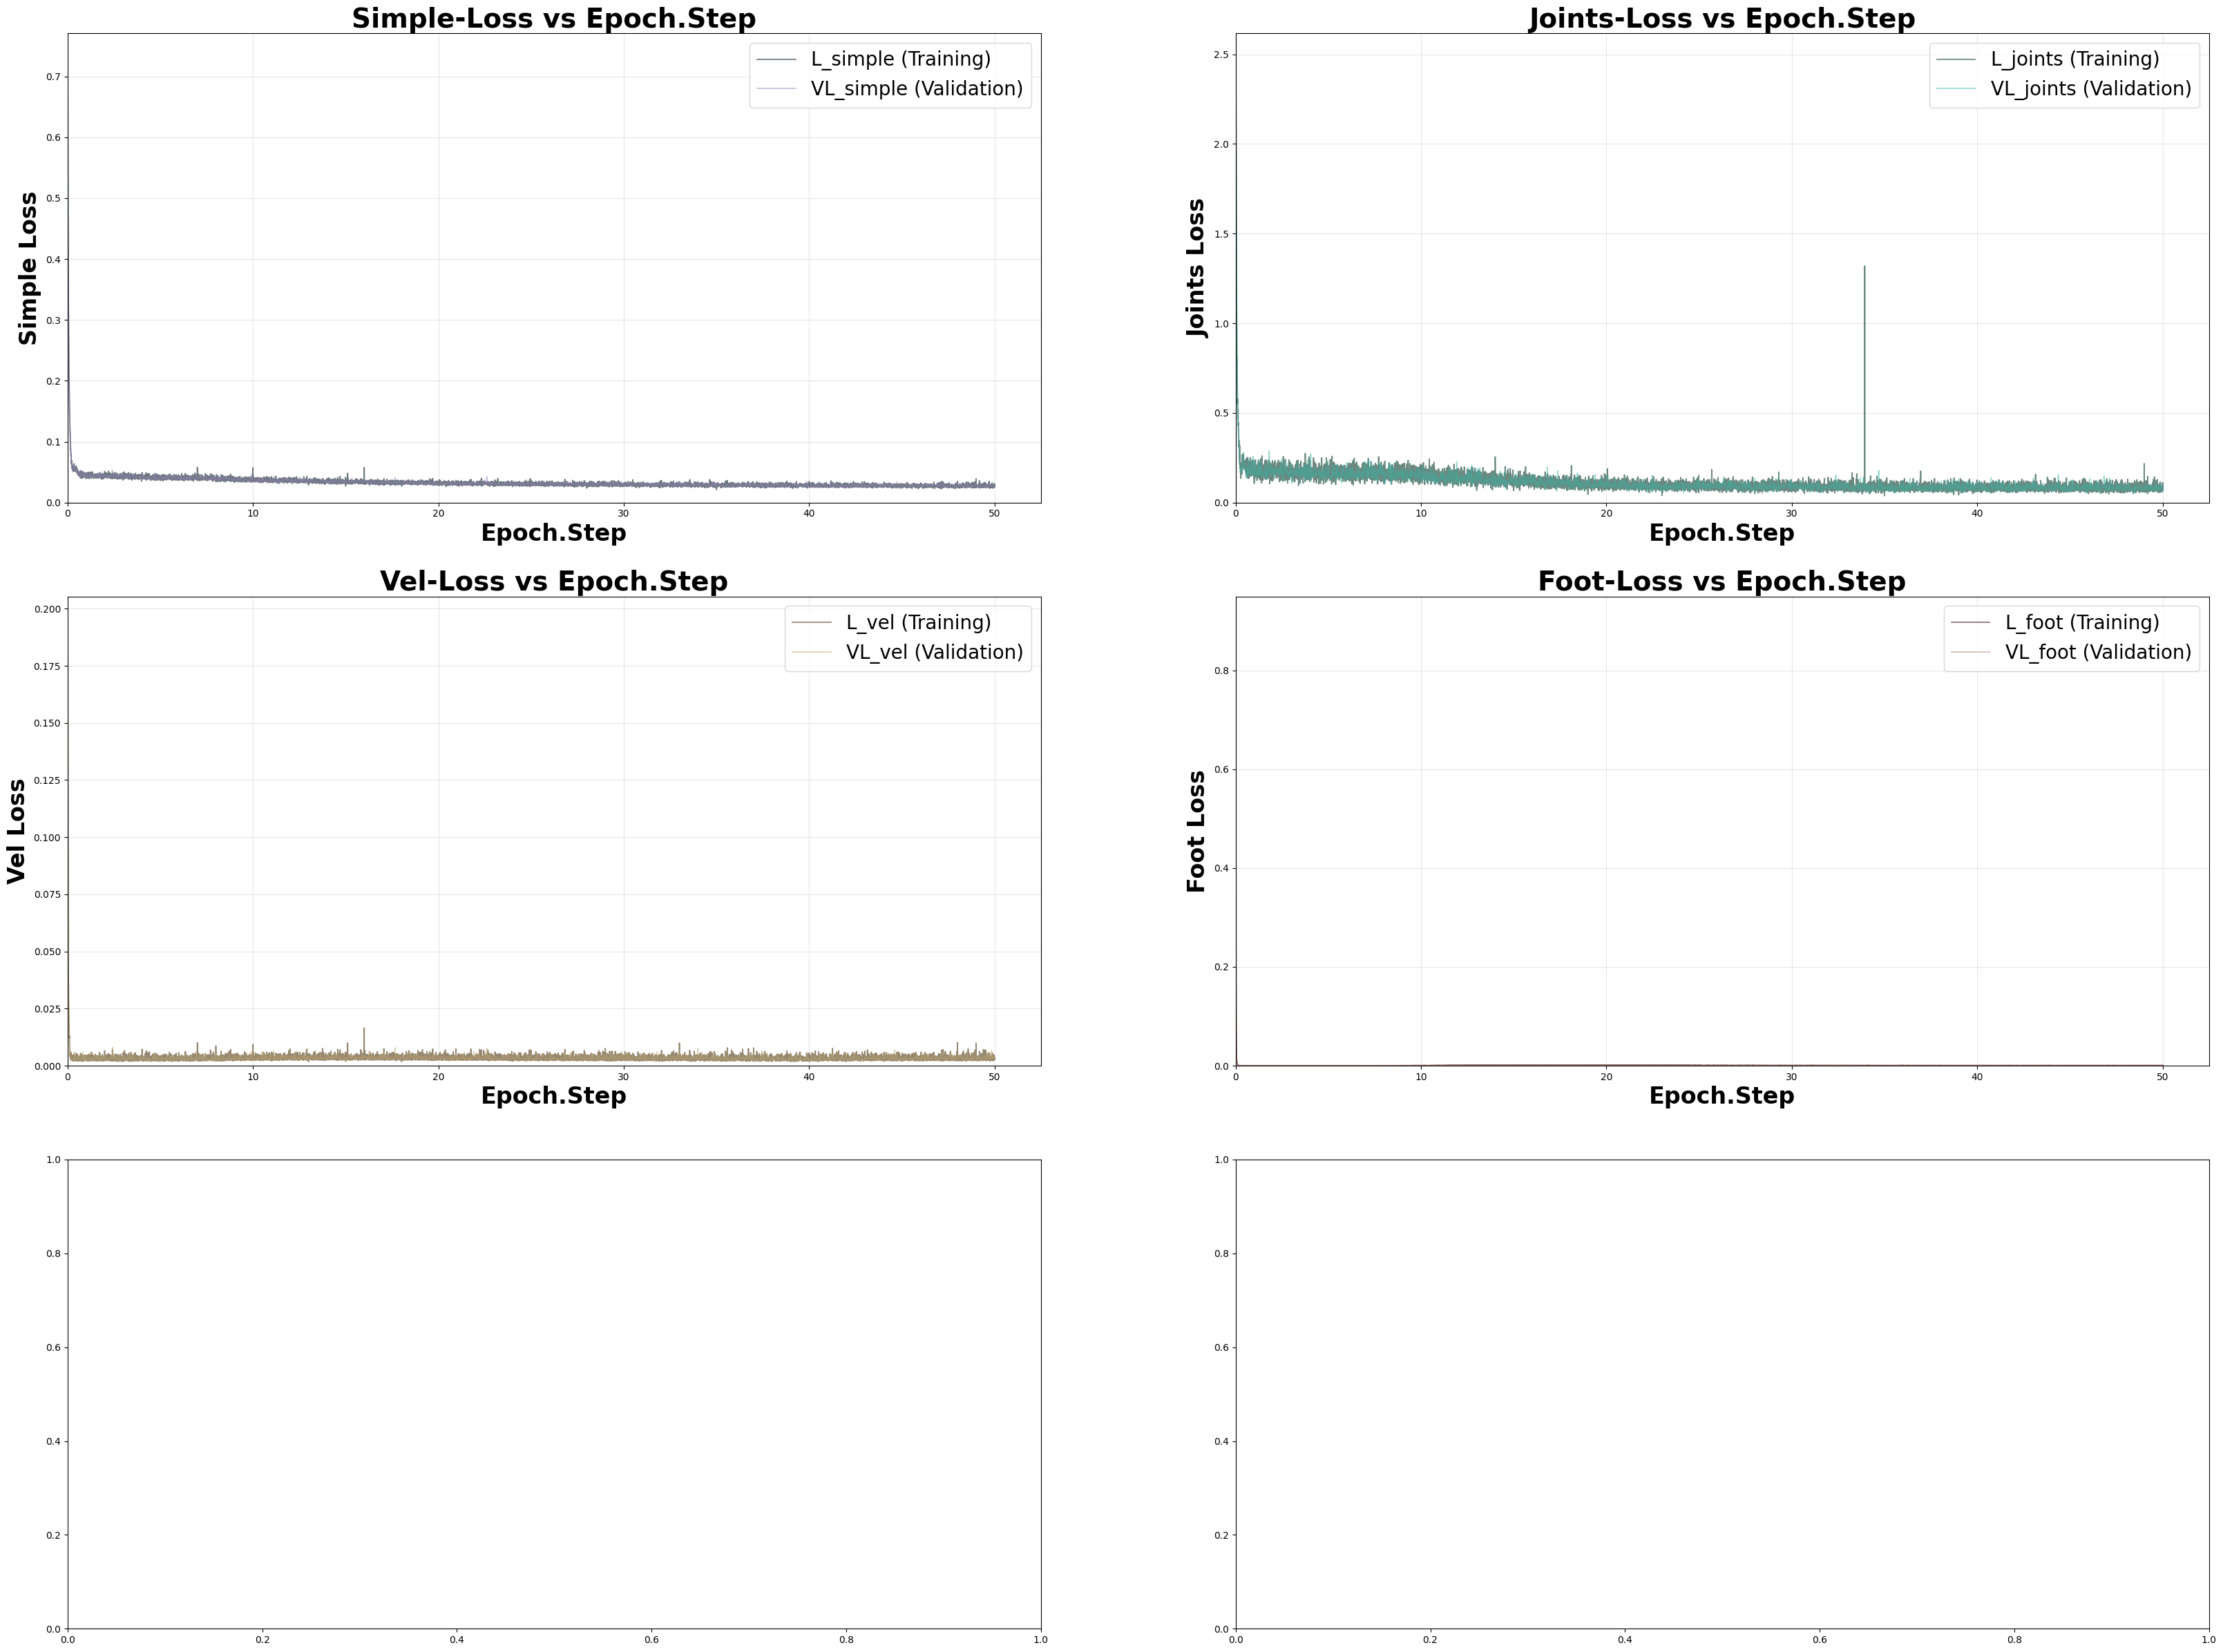

In [54]:
fig, axes = plt.subplots(3, 2, figsize=(40, 30))
axes = axes.flatten()

for idx, component in enumerate(loss_components):
	ax = axes[idx]

	l_col = f'L_{component}'
	vl_col = f'VL_{component}'

	# Plot training loss
	ax.plot(df_clean['epoch_step_numeric'], df_clean[l_col], 
			label=f'{l_col} (Training)', color=colors_train[idx], 
			linewidth=1.252, alpha=0.6)

	# Plot validation loss
	valid_mask = df_clean[vl_col].notna()
	ax.plot(df_clean.loc[valid_mask, 'epoch_step_numeric'], 
			df_clean.loc[valid_mask, vl_col], 
			label=f'{vl_col} (Validation)', color=colors_val[idx], 
			linewidth=1.25, alpha=0.5)

	ax.set_xlabel('Epoch.Step', fontsize=24, fontweight='bold')
	ax.set_ylabel(f'{component.capitalize()} Loss', fontsize=24, fontweight='bold')
	ax.set_title(f'{component.capitalize()}-Loss vs Epoch.Step', fontsize=28, fontweight='bold')
	ax.legend(fontsize=20)
	ax.grid(True, alpha=0.3)
	ax.set_xlim(left=0)
	ax.set_ylim(bottom=0)
	
plt.tight_layout()
plt.savefig(PLOT_DIR/f'#3 {[comp.capitalize()for comp in loss_components]}-Loss vs Epoch.Step.png')
plt.show()


### Mean Losses vs Epoch

In [55]:
# Group by epoch and calculate mean
cols = [c for c in df_clean.columns if c.startswith('L_') or c.startswith('VL_')]
df_mean = df_clean.groupby('epoch')[cols].mean().reset_index()
print("Mean Loss per Epoch - Shape:", df_mean.shape)
print("\nFirst few rows:")
print(df_mean.head())

Mean Loss per Epoch - Shape: (50, 11)

First few rows:
   epoch   L_total  L_simple  L_joints     L_vel        L_foot  VL_total  \
0      1  0.445831  0.087851  0.333690  0.009692  1.459817e-02  0.077121   
1      2  0.220786  0.043994  0.173669  0.003122  1.206906e-06  0.044829   
2      3  0.217920  0.043384  0.171433  0.003102  9.459076e-07  0.044673   
3      4  0.214138  0.042529  0.168503  0.003105  1.124796e-06  0.042531   
4      5  0.211620  0.041302  0.167215  0.003103  1.237199e-06  0.041558   

   VL_simple  VL_joints    VL_vel       VL_foot  
0   0.077680   0.298116  0.006614  3.192995e-03  
1   0.043979   0.176990  0.003173  1.125012e-06  
2   0.043763   0.176319  0.003284  9.243264e-07  
3   0.042151   0.167497  0.003006  1.074168e-06  
4   0.040824   0.163957  0.003009  1.213619e-06  


#### Mean Total Loss vs Epoch

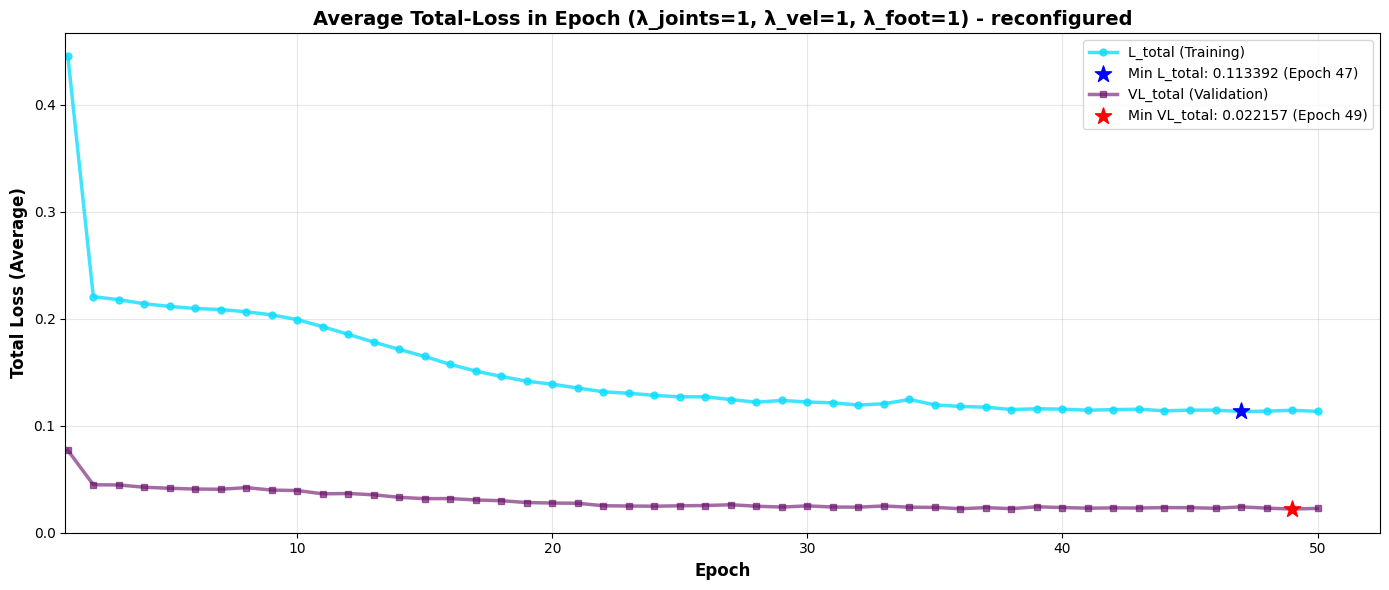

In [56]:
def plot_loss_vs_epoch(df, typ=""):
	plt.figure(figsize=(14, 6))

	# Plot training loss
	plt.plot(df['epoch'], df['L_total'], 
			label='L_total (Training)', color=colors[0], linewidth=2.5, marker='o', markersize=5, alpha=0.8)

	# Find and highlight minimum training loss
	min_train_idx = df['L_total'].idxmin()
	min_train_epoch = df.loc[min_train_idx, 'epoch']
	min_train_loss = df.loc[min_train_idx, 'L_total']
	plt.scatter(min_train_epoch, min_train_loss, color='blue', s=150, 
				marker='*', zorder=5, label=f'Min L_total: {min_train_loss:.6f} (Epoch {min_train_epoch})')

	# Plot validation loss
	plt.plot(df['epoch'], df['VL_total'], 
			label='VL_total (Validation)', color=colors[1], linewidth=2.5, marker='s', markersize=5, alpha=0.6)

	# Find and highlight minimum validation loss
	min_val_idx = df['VL_total'].idxmin()
	min_val_epoch = df.loc[min_val_idx, 'epoch']
	min_val_loss = df.loc[min_val_idx, 'VL_total']
	plt.scatter(min_val_epoch, min_val_loss, color='red', s=150, 
				marker='*', zorder=5, label=f'Min VL_total: {min_val_loss:.6f} (Epoch {min_val_epoch})')

	plt.xlabel('Epoch', fontsize=12, fontweight='bold')
	plt.ylabel(f'Total Loss ({typ})', fontsize=12, fontweight='bold')
	plt.title(f'{typ} Total-Loss in Epoch {lambda_values}', fontsize=14, fontweight='bold')
	plt.legend(fontsize=10)
	plt.grid(True, alpha=0.3)
	plt.xlim(left=.9)
	plt.ylim(bottom=0)
	plt.tight_layout()
	plt.savefig(PLOT_DIR/("#1 "+plt.gca().get_title()+'.png'))
	plt.show()

plot_loss_vs_epoch(df_mean, "Average")

In [57]:
def plot_std_vs_epoch(df, typ=""):
	plt.figure(figsize=(14, 6))

	# Plot training std
	plt.plot(df['epoch'], df['L_gt_std'], label='L_gt_std (Training - Ground Truth)', color=colors[2], 
			linewidth=2, linestyle='--', marker='o', markersize=5, alpha=0.5)

	plt.plot(df['epoch'], df['L_pred_std'], label='L_pred_std (Training - Prediction)', color=colors[0], 
			linewidth=2.5, marker='o', markersize=5, alpha=0.6)

	# Find and highlight minimum training pred_std
	max_train_idx = df['L_pred_std'].idxmax()
	max_train_epoch = df.loc[max_train_idx, 'epoch']
	max_train_loss = df.loc[max_train_idx, 'L_pred_std']
	plt.scatter(max_train_epoch, max_train_loss, color='blue', s=150, 
				marker='*', zorder=5, label=f'Max L_pred_std: {max_train_loss:.6f} (Epoch {max_train_epoch})')

	# Plot validation std
	valid_mask = df['VL_gt_std'].notna()
	plt.plot(df.loc[valid_mask, 'epoch'], df.loc[valid_mask, 'VL_gt_std'], 
			label='VL_gt_std (Validation - Ground Truth)', color=colors[3], linewidth=2, linestyle='--', marker='s', markersize=5, alpha=0.4)

	valid_mask = df['VL_pred_std'].notna()
	plt.plot(df.loc[valid_mask, 'epoch'], df.loc[valid_mask, 'VL_pred_std'], 
			label='VL_pred_std (Validation - Prediction)', color=colors[1], linewidth=2.5, marker='s', markersize=5, alpha=0.5)

	# Find and highlight minimum validation pred_std
	max_val_idx = df['VL_pred_std'].idxmax()
	max_val_epoch = df.loc[max_val_idx, 'epoch']
	max_val_loss = df.loc[max_val_idx, 'VL_pred_std']
	plt.scatter(max_val_epoch, max_val_loss, color='red', s=150, 
				marker='*', zorder=5, label=f'Max VL_pred_std: {max_val_loss:.6f} (Epoch {max_val_epoch})')

	plt.xlabel('Epoch', fontsize=12, fontweight='bold')
	plt.ylabel(f'Std Across Frames ({typ})', fontsize=12, fontweight='bold')
	plt.title(f'{typ} Standard Deviation in Each Epoch', fontsize=14, fontweight='bold')
	plt.legend(fontsize=10)
	plt.grid(True, alpha=0.3)
	plt.xlim(left=.9)
	plt.ylim(bottom=0)
	plt.tight_layout()
	plt.savefig(PLOT_DIR/("#2 "+plt.gca().get_title()+'.png'))
	plt.show()

plot_std_vs_epoch(df_mean, "Average")

KeyError: 'L_gt_std'

<Figure size 1400x600 with 0 Axes>

#### Mean Individual Losses [L_simple, L_joints, L_vel, L_foot] vs Epoch

KeyError: 'L_temporal'

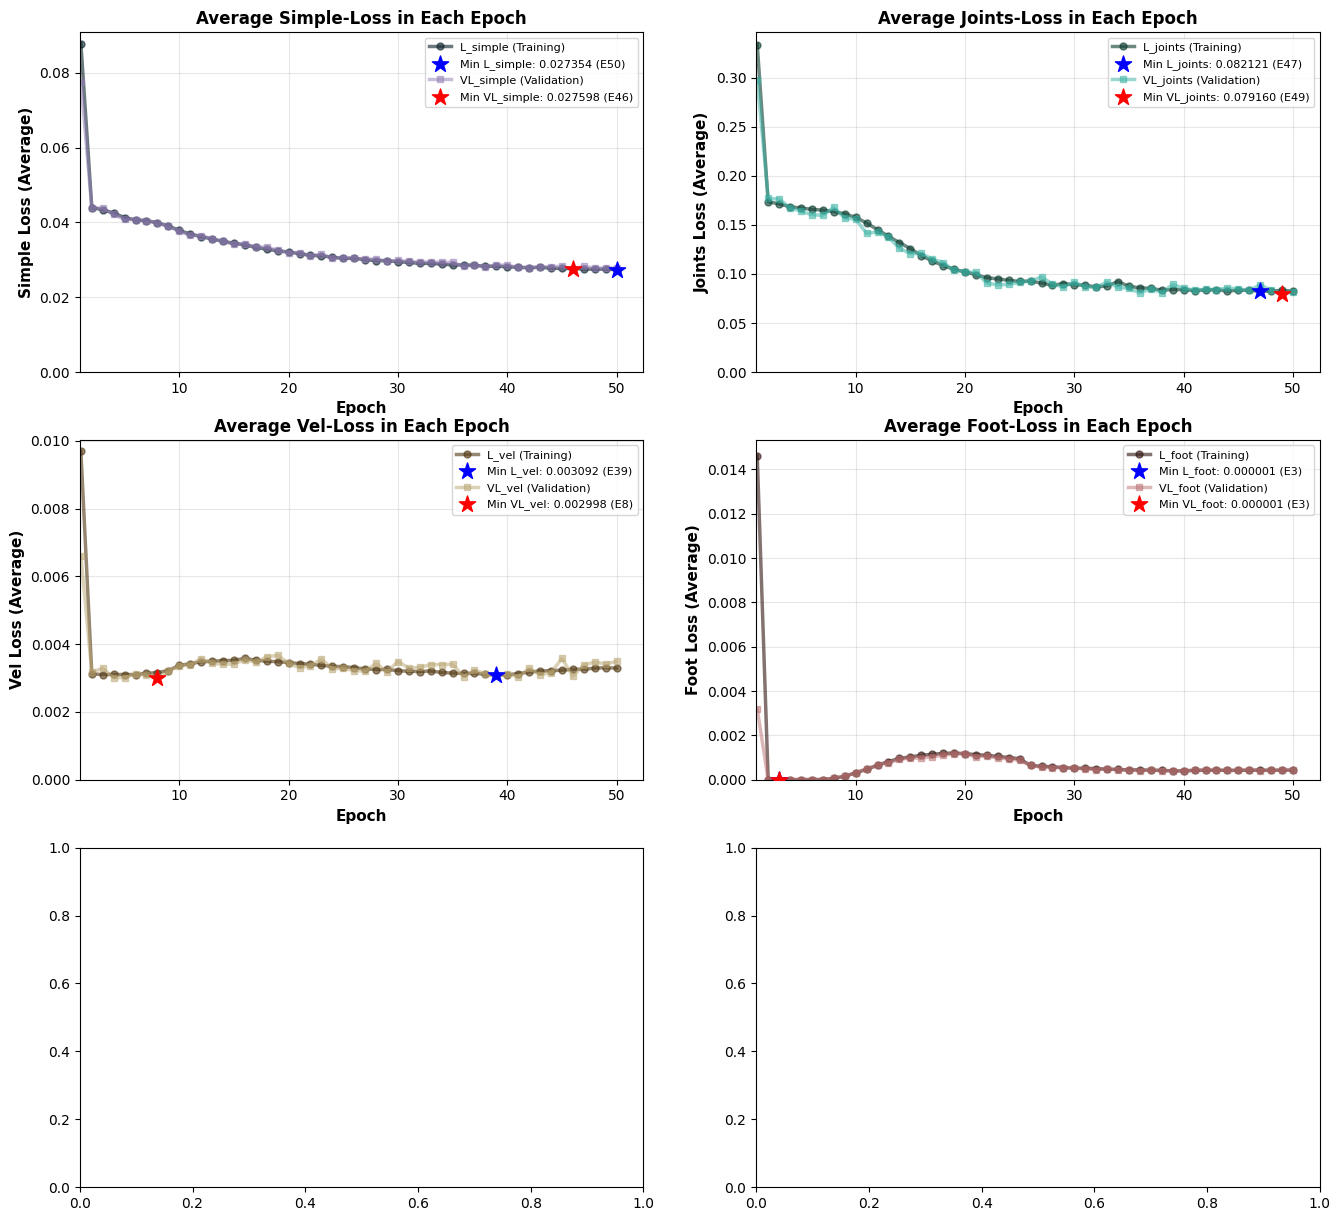

In [58]:
def plot_comps_vs_epoch(df, typ=""):
	fig, axes = plt.subplots(3, 2, figsize=(16, 15))
	axes = axes.flatten()

	for idx, component in enumerate(loss_components):
		ax = axes[idx]

		l_col = f'L_{component}'
		vl_col = f'VL_{component}'

		# Plot training loss
		ax.plot(df['epoch'], df[l_col], 
				label=f'{l_col} (Training)', color=colors_train[idx], 
				linewidth=2.5, marker='o', markersize=5, alpha=0.6)

		# Find and highlight minimum training loss
		min_train_idx = df[l_col].idxmin()
		min_train_epoch = df.loc[min_train_idx, 'epoch']
		min_train_loss = df.loc[min_train_idx, l_col]
		ax.scatter(min_train_epoch, min_train_loss, color='blue', s=150, 
					marker='*', zorder=5, 
					label=f'Min {l_col}: {min_train_loss:.6f} (E{min_train_epoch})')

		# Plot validation loss
		valid_mask = df[vl_col].notna()
		if valid_mask.any():
			ax.plot(df.loc[valid_mask, 'epoch'], 
					df.loc[valid_mask, vl_col], 
					label=f'{vl_col} (Validation)', color=colors_val[idx], 
					linewidth=2.5, marker='s', markersize=5, alpha=0.5)
			
			# Find and highlight minimum validation loss
			min_val_idx = df.loc[valid_mask, vl_col].idxmin()
			min_val_epoch = df.loc[min_val_idx, 'epoch']
			min_val_loss = df.loc[min_val_idx, vl_col]
			ax.scatter(min_val_epoch, min_val_loss, color='red', s=150, 
						marker='*', zorder=5, 
						label=f'Min {vl_col}: {min_val_loss:.6f} (E{min_val_epoch})')

		ax.set_xlabel('Epoch', fontsize=11, fontweight='bold')
		ax.set_ylabel(f'{component.capitalize()} Loss ({typ})', fontsize=11, fontweight='bold')
		ax.set_title(f'{typ} {component.capitalize()}-Loss in Each Epoch', fontsize=12, fontweight='bold')
		ax.legend(fontsize=8)
		ax.grid(True, alpha=0.3)
		ax.set_xlim(left=.9)
		ax.set_ylim(bottom=0)

	plt.tight_layout()
	plt.savefig(PLOT_DIR/f"#3 {typ} {[comp.capitalize()for comp in loss_components]}-Loss in Each Epoch.png")
	plt.show()

plot_comps_vs_epoch(df_mean, "Average")

### Last Step Losses vs Epoch (with min-loss highlighted)

In [ ]:
# Group by epoch and take the last step (highest step value)
df_last = df_clean.loc[df_clean.groupby('epoch')['step'].idxmax()].copy()
print("Last Step per Epoch - Shape:", df_last.shape)
print("\nFirst few rows:")
print(df_last.head())

Last Step per Epoch - Shape: (65, 22)

First few rows:
      epoch   step   L_total  L_pred_std  L_gt_std  L_simple  L_joints  \
204       1  26130  0.150719    0.007863  0.138844  0.023245  0.125577   
409       2  26130  0.037693    0.010376  0.122946  0.012187  0.024959   
614       3  26130  0.047944    0.024605  0.130452  0.012417  0.034581   
819       4  26130  0.095440    0.032470  0.135892  0.017137  0.077188   
1024      5  26130  0.034256    0.042096  0.117681  0.010764  0.022408   

         L_vel    L_foot  L_temporal  ...  VL_pred_std  VL_gt_std  VL_simple  \
204   0.001865  0.000032    0.002627  ...     0.007970   0.127051   0.014561   
409   0.000516  0.000032    0.000384  ...     0.010045   0.131324   0.013947   
614   0.000883  0.000062    0.000973  ...     0.022289   0.126564   0.013558   
819   0.001049  0.000066    0.001602  ...     0.027111   0.129318   0.012206   
1024  0.000961  0.000122    0.001413  ...     0.040030   0.139920   0.012359   

      VL_joints    

#### Last Step Total Loss vs Epoch

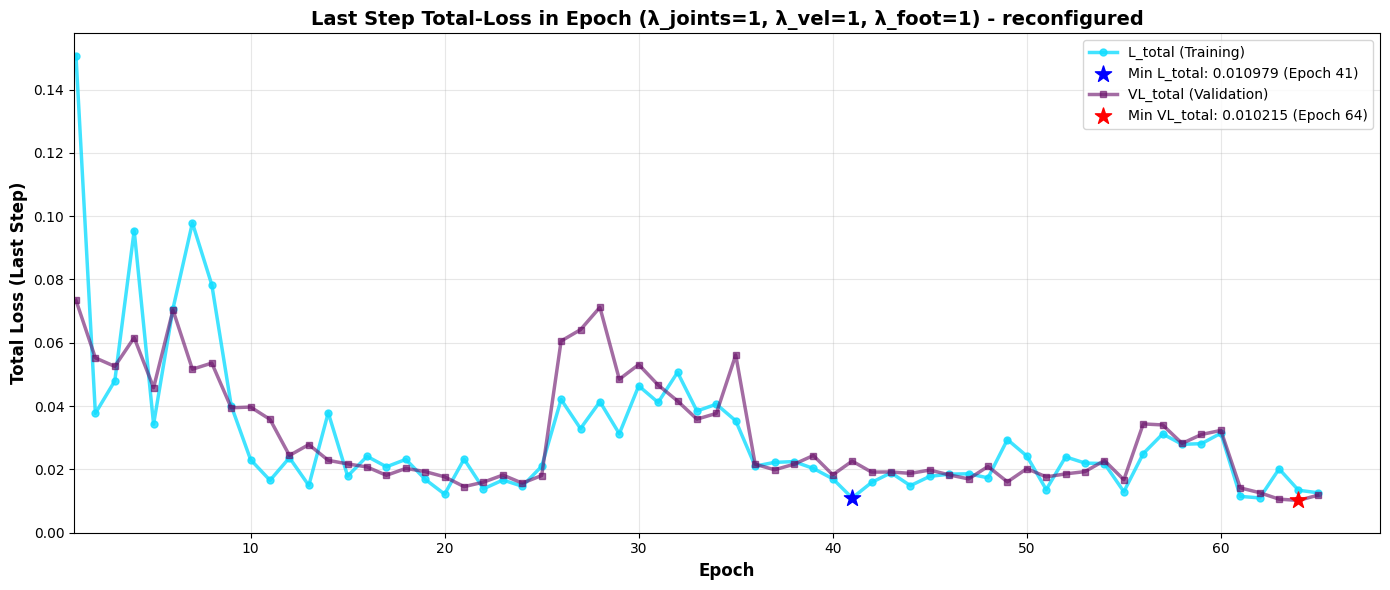

In [ ]:
plot_loss_vs_epoch(df_last, "Last Step")

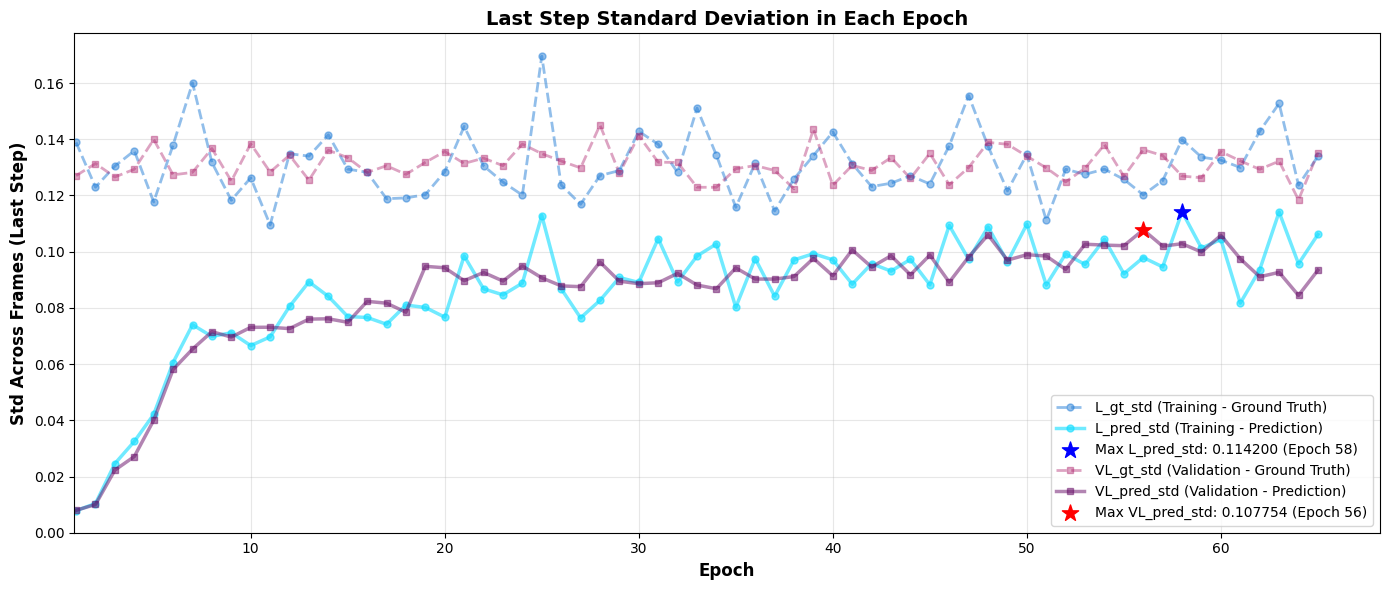

In [59]:
plot_std_vs_epoch(df_last, "Last Step")

#### Last Step Individual Losses [L_simple, L_joints, L_vel, L_foot] vs Epoch

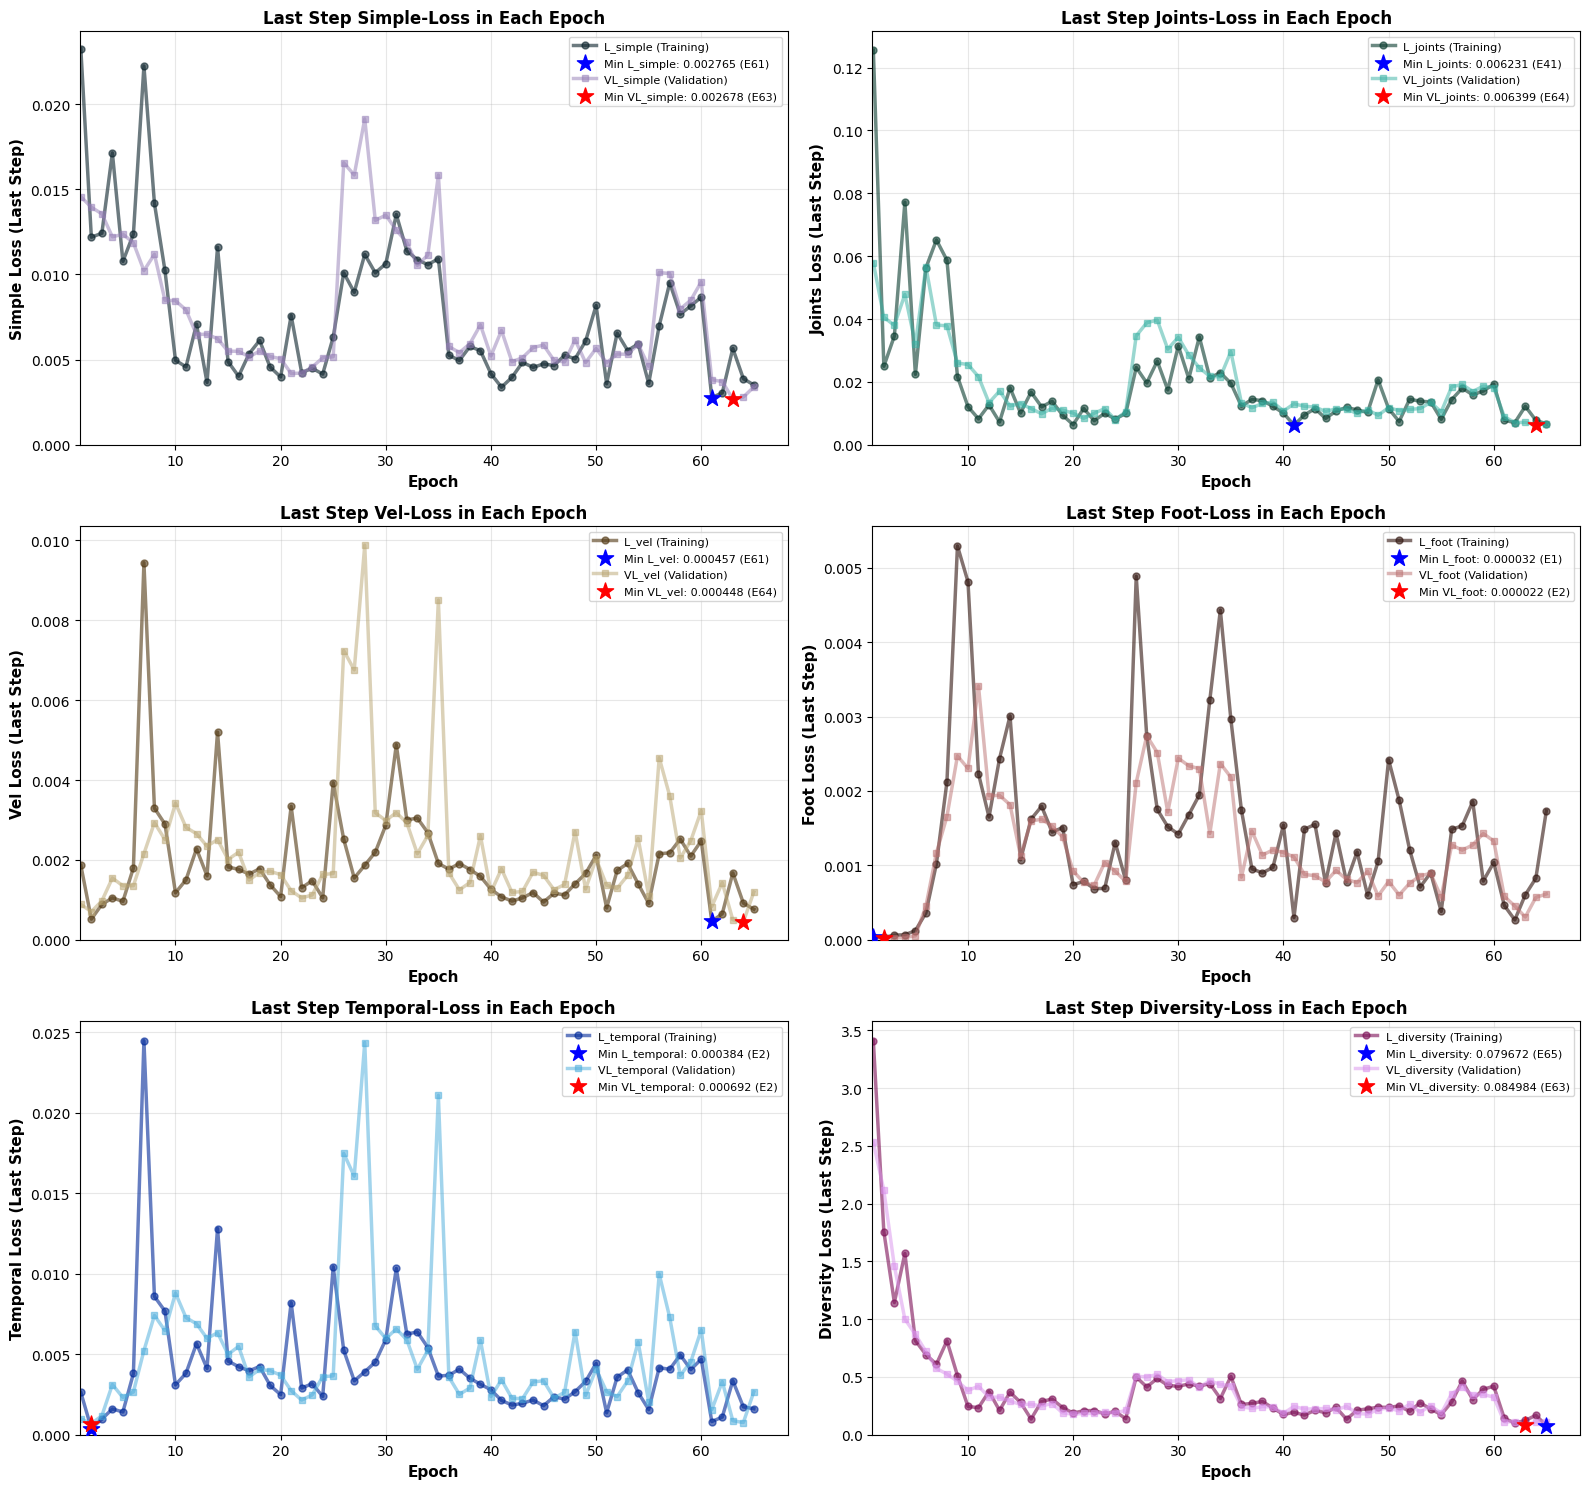

In [60]:
plot_comps_vs_epoch(df_last, "Last Step")

#### Summary Statistics

In [61]:
# Print summary statistics for each epoch
def print_summary(df, typ=""):
	print("=" * 50)
	print(f"SUMMARY STATISTICS - {typ} in Each Epoch")
	print("=" * 50)

	print("\nTraining Loss - Minimum Values:")
	for component in ['total', 'pred_std']+loss_components:
		col = f'L_{component}'
		min_idx = df[col].idxmin()
		min_epoch = df.loc[min_idx, 'epoch']
		min_value = df.loc[min_idx, col]
		print(f"  {col:12s}: {min_value:.8f} at Epoch {min_epoch}")

	print("\nValidation Loss - Minimum Values:")
	for component in ['total', 'pred_std']+loss_components:
		col = f'VL_{component}'
		valid_data = df[df[col].notna()]
		if len(valid_data) > 0:
			min_idx = valid_data[col].idxmin()
			min_epoch = valid_data.loc[min_idx, 'epoch']
			min_value = valid_data.loc[min_idx, col]
			print(f"  {col:12s}: {min_value:.8f} at Epoch {min_epoch}")
		else:
			print(f"  {col:12s}: No valid data")
	print()

print_summary(df_mean, "Average")
print_summary(df_last, "Last Step")

SUMMARY STATISTICS - Average in Each Epoch

Training Loss - Minimum Values:
  L_total     : 0.11339186 at Epoch 47


KeyError: 'L_pred_std'

---

## Evaluation Metrics

In [62]:
import os, glob, torch, pickle
import numpy as np
from torch.utils.data import DataLoader
from include.loss_utils import smpl_skeleton

DATA_DIR = Path.cwd() / "datasets"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# >>> USER: set this to the folder containing your preprocessed .npz files
processed_data_dir = DATA_DIR / "AIST/processed" 
motions_data_dir = DATA_DIR / "AIST/motions" 

files = sorted(glob.glob(os.path.join(processed_data_dir, "*.npz")))
print("No. of Preprocessed data-files found:", len(files))

Device: cuda
No. of Preprocessed data-files found: 4355


In [ ]:
ds = ViMoDataset(files, t_views=9) # all files loader
dl = DataLoader(ds, batch_size=1, shuffle=True, pin_memory=True)
it = iter(dl)

#best_epoch = df_last.loc[df_last['L_total'].idxmin(), 'epoch']
last_epoch = df_last['epoch'].iloc[-1]
#last_epoch = 50
model_path = MODEL_DIR / (f"Epoch{last_epoch}" + "_ckpt.pth")
ckpt = torch.load(model_path, map_location=device)

model.load_state_dict(ckpt['model_state'])
print("Loaded model checkpoint from", model_path)

Loaded model checkpoint from d:\STUDIES\MTech\#MTP\codes\vimo\outputs\ViMo(m=151,p=51,t=1000,d=128,h=4,ml=3,pl=2,c=0.25)_Adan(wd=0.02)\run_v1_warm50\models\Epoch50_ckpt.pth


In [65]:
from pytorch3d import transforms
from include.loss_utils import fk_for_worldpos

# Load AIST++ data and extract joint positions
def load_aist_motion(motion_data):
	#print("Motion keys:", motion_data.keys())

	# Extract parameters
	poses = torch.tensor(motion_data['smpl_poses'][::2])  # (S, 24, 3)
	trans = torch.tensor(motion_data['smpl_trans'][::2])  # (S, 3)
	scaling = torch.tensor(motion_data['smpl_scaling'])  # scalar
	trans_norm = trans / scaling # Normalize to canonical scale
	S = poses.shape[0]
	#print(f"smpl_poses shape: {poses.shape}, max-abs:{poses.abs().max().item()}")
	#print(f"smpl_trans shape: {trans.shape}, max-abs:{trans.abs().max().item()}")
	#print(f"smpl_scaling: {scaling}")

	rmats = transforms.axis_angle_to_matrix(poses.reshape(S, 24, 3))
	poses = transforms.matrix_to_axis_angle(rmats).reshape(-1, 24*3) 
	joint_positions = fk_for_worldpos(rmats, trans_norm)[0].cpu().numpy()
	return joint_positions


---

In [ ]:
from include.viz_utils import animate_3d_skeleton
# EVALUATE ACROSS VARIOUS TIMESTEPS
batch = next(it)
T = model.max_T # 1000
diff_step = int(T*5/100) # 50
const_pose_limit = 3
make_beta_schedule(T, device=device)

model.to(device) # move to target device
m_gt = batch['m3d'].to(device) # (B, S=150, 151 => 24*4 + 4 + 3)
p2d = batch['p2d'].to(device) # (B, S=150, 51 => 17*3)
f_names = [os.path.splitext(name)[0] for name in batch['file_name']] # remove extention
out_paths = [name.split('_clip') for name in f_names]
m_og = [pickle.load(open(motions_data_dir / (f[0] + '.pkl'), 'rb')) for f in out_paths]

const_pose_count = 0
for i in range(diff_step,T,diff_step):
	# Deterministic Sampling
	t_step = torch.full((m_gt.shape[0],), i, dtype=torch.long, device=device) # t=T-1 (largest noise)
	x_t = forward_diffusion_sample(m_gt, t_step)
	m_pe = reverse_denoising_sample(model, x_t, t_step, p2d, verbose=False) # final prediction estimate

	# Stochastic Sampling
	m_sg = reverse_denoising_sample(model, x_t, t_step, p2d, stochasticity=True, verbose=False) # stochastic generation

	# Compare with original data as well, to spot mistakes in preprocessing
	j3d_pos_og = load_aist_motion(m_og[0])
	j3d_pos_gt = get_joint_positions(m_gt).cpu().numpy() # (B, S, J=24, 3=(x,y,z))
	j3d_pos_pe = get_joint_positions(m_pe).cpu().numpy()
	j3d_pos_sg = get_joint_positions(m_sg).cpu().numpy()

	# Check if predictions are constant
	j6d_pred_gt = m_gt[:, :, :-7].reshape(1, 150, 24, 6)
	rmats_pred_gt = transforms.rotation_6d_to_matrix(j6d_pred_gt)
	j6d_pred_pe = m_pe[:, :, :-7].reshape(1, 150, 24, 6)
	rmats_pred_pe = transforms.rotation_6d_to_matrix(j6d_pred_pe)
	# Compute frame-to-frame difference
	frame_diff_gt = (rmats_pred_gt[:, 1:] - rmats_pred_gt[:, :-1]).abs().mean()
	frame_diff_pe = (rmats_pred_pe[:, 1:] - rmats_pred_pe[:, :-1]).abs().mean()
	print(f"Average frame-to-frame rotation change: (timestep={i}, gt={frame_diff_gt.item():.6f}, pe={frame_diff_pe.item():.6f})", end=" ")

	# Should be > 0.01 for real motion, near 0 for frozen pose
	if frame_diff_pe < frame_diff_gt*0.1:
		print("⚠️ CONFIRMED: Model predicts constant pose!")
		const_pose_count += 1
		if (const_pose_count > const_pose_limit): break # exit eval if outputs are only const poses
	else: print()

	# Usage with your data - Animate single sequence
	save_path_splits = out_paths[0]
	if i == diff_step: # save only once
		animate_3d_skeleton(j3d_pos_gt[0], PLOT_DIR / f"{save_path_splits[0]}/{save_path_splits[1]} ground_truth.gif", fps=30, create_subplot=True, subplot_interval=10)
		animate_3d_skeleton(j3d_pos_og, PLOT_DIR / f"{save_path_splits[0]}/original_data.gif", fps=30)

	animate_3d_skeleton(j3d_pos_pe[0], PLOT_DIR / f"{save_path_splits[0]}/{save_path_splits[1]} predicted_estimate(t={i}).gif", fps=30, create_subplot=True, subplot_interval=10)
	animate_3d_skeleton(j3d_pos_sg[0], PLOT_DIR / f"{save_path_splits[0]}/{save_path_splits[1]} stochastic_generation(t={i}).gif", fps=30, create_subplot=True, subplot_interval=10)
	print()

Average frame-to-frame rotation change: (timestep=50, gt=0.026378, pe=0.006590) 
Animation saved (150 frames at 30 fps) @\gLH_sBM_cAll_d16_mLH2_ch07\[0138-0288] ground_truth.gif
Frame subplot saved (16 frames) @\gLH_sBM_cAll_d16_mLH2_ch07\[0138-0288] ground_truth_frames.png
Animation saved (288 frames at 30 fps) @\gLH_sBM_cAll_d16_mLH2_ch07\original_data.gif
Animation saved (150 frames at 30 fps) @\gLH_sBM_cAll_d16_mLH2_ch07\[0138-0288] predicted_estimate(t=50).gif
Frame subplot saved (16 frames) @\gLH_sBM_cAll_d16_mLH2_ch07\[0138-0288] predicted_estimate(t=50)_frames.png
Animation saved (150 frames at 30 fps) @\gLH_sBM_cAll_d16_mLH2_ch07\[0138-0288] stochastic_generation(t=50).gif
Frame subplot saved (16 frames) @\gLH_sBM_cAll_d16_mLH2_ch07\[0138-0288] stochastic_generation(t=50)_frames.png

Average frame-to-frame rotation change: (timestep=100, gt=0.026378, pe=0.004876) 
Animation saved (150 frames at 30 fps) @\gLH_sBM_cAll_d16_mLH2_ch07\[0138-0288] predicted_estimate(t=100).gif
Fram

---